In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
import os
import glob
import xarray as xr
import rioxarray as rio
import geopandas as gpd

In [4]:
# NO2 VCD GAPFILLED
# Path Data Time Series NO2 VCD
no2_path = r'C:\Users\zaviezra\Documents\UNDIP\TA\02skripsi\02processing\Data\GAPFILL' 
no2_files = glob.glob(os.path.join(no2_path, 'no2_gap_*.tif'))
no2_files.sort()


# Read All NO2 VCD
no2_dataset = []
for file in no2_files:
    data_no2 = rio.open_rasterio(file)
    no2_dataset.append(data_no2)

# Extract Date
dates = [file.split('no2_gap_')[-1].replace('.tif', '') for file in no2_files]
time_no2= pd.to_datetime(dates, format='%Y%m%d')

# Combined Dataset to Xarray
no2_gap = xr.concat(no2_dataset, dim='time').squeeze('band')
no2_gap['time'] = time_no2

# Temporal Aggregation (Monthly Mean)
monthly_mean = no2_gap.groupby('time.month').mean(dim='time')

# View generate metadata associated with the raster file
print("Bounding Box:", monthly_mean.rio.bounds())
print("The crs of your data is:", monthly_mean.rio.crs)
print("The nodatavalue of your data is:", monthly_mean.rio.nodata)
print("The shape of your data is:", monthly_mean.shape)
print("The spatial resolution for your data is:", monthly_mean.rio.resolution())
print("The metadata for your data is:", monthly_mean.attrs)


Bounding Box: (412997.2, 9210616.800000003, 449732.8, 9240673.200000001)
The crs of your data is: PROJCS["WGS 84 / UTM zone 49S",GEOGCS["WGS 84",DATUM["World Geodetic System 1984",SPHEROID["WGS 84",6378137,298.257223563]],PRIMEM["Greenwich",0],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",111],PARAMETER["scale_factor",0.9996],PARAMETER["false_easting",500000],PARAMETER["false_northing",10000000],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH]]
The nodatavalue of your data is: None
The shape of your data is: (6, 27, 33)
The spatial resolution for your data is: (1113.2000000000007, 1113.1999999999714)
The metadata for your data is: {'AREA_OR_POINT': 'Area', 'scale_factor': 1.0, 'add_offset': 0.0, 'long_name': 'no2_vcd_filled'}


# **Hotspot Metode Top 20% Persentil - Monthly**

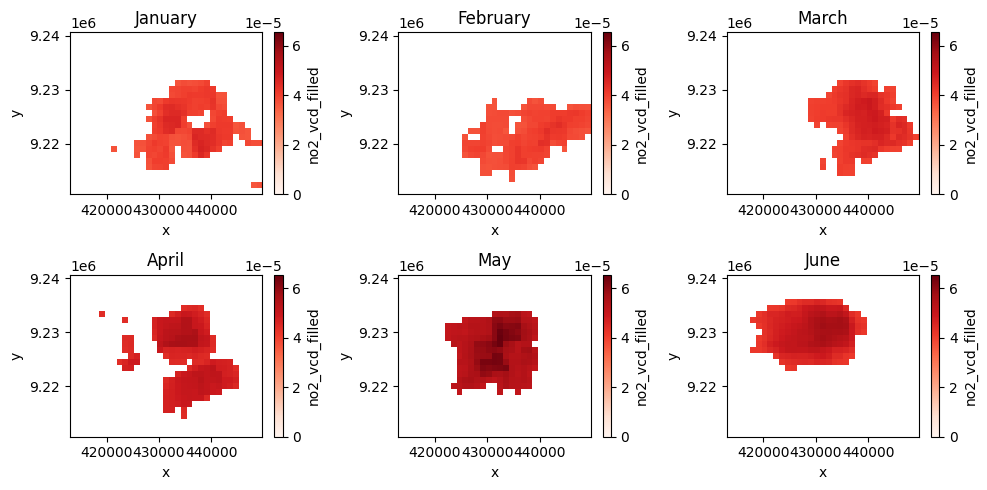

In [5]:
import numpy as np
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 3, figsize=(10, 5))

month_name = ['January', 'February', 'March', 'April', 'May', 'June']

for i, ax in enumerate(axes.flatten()):
    if i < len(month_name):
        month_i = monthly_mean.sel(month=i+1)

        # threshold P80
        data = month_i.values.flatten()
        data = data[~np.isnan(data)]
        p80 = np.percentile(data, 80)

        hotspot_i = month_i.where(month_i >= p80)

        hotspot_i.plot(
            ax=ax,
            cmap='Reds',
            vmin=0,
            vmax=np.nanmax(monthly_mean.values)
        )

        ax.set_title(month_name[i])
    else:
        ax.axis('off')

plt.tight_layout()
plt.show()

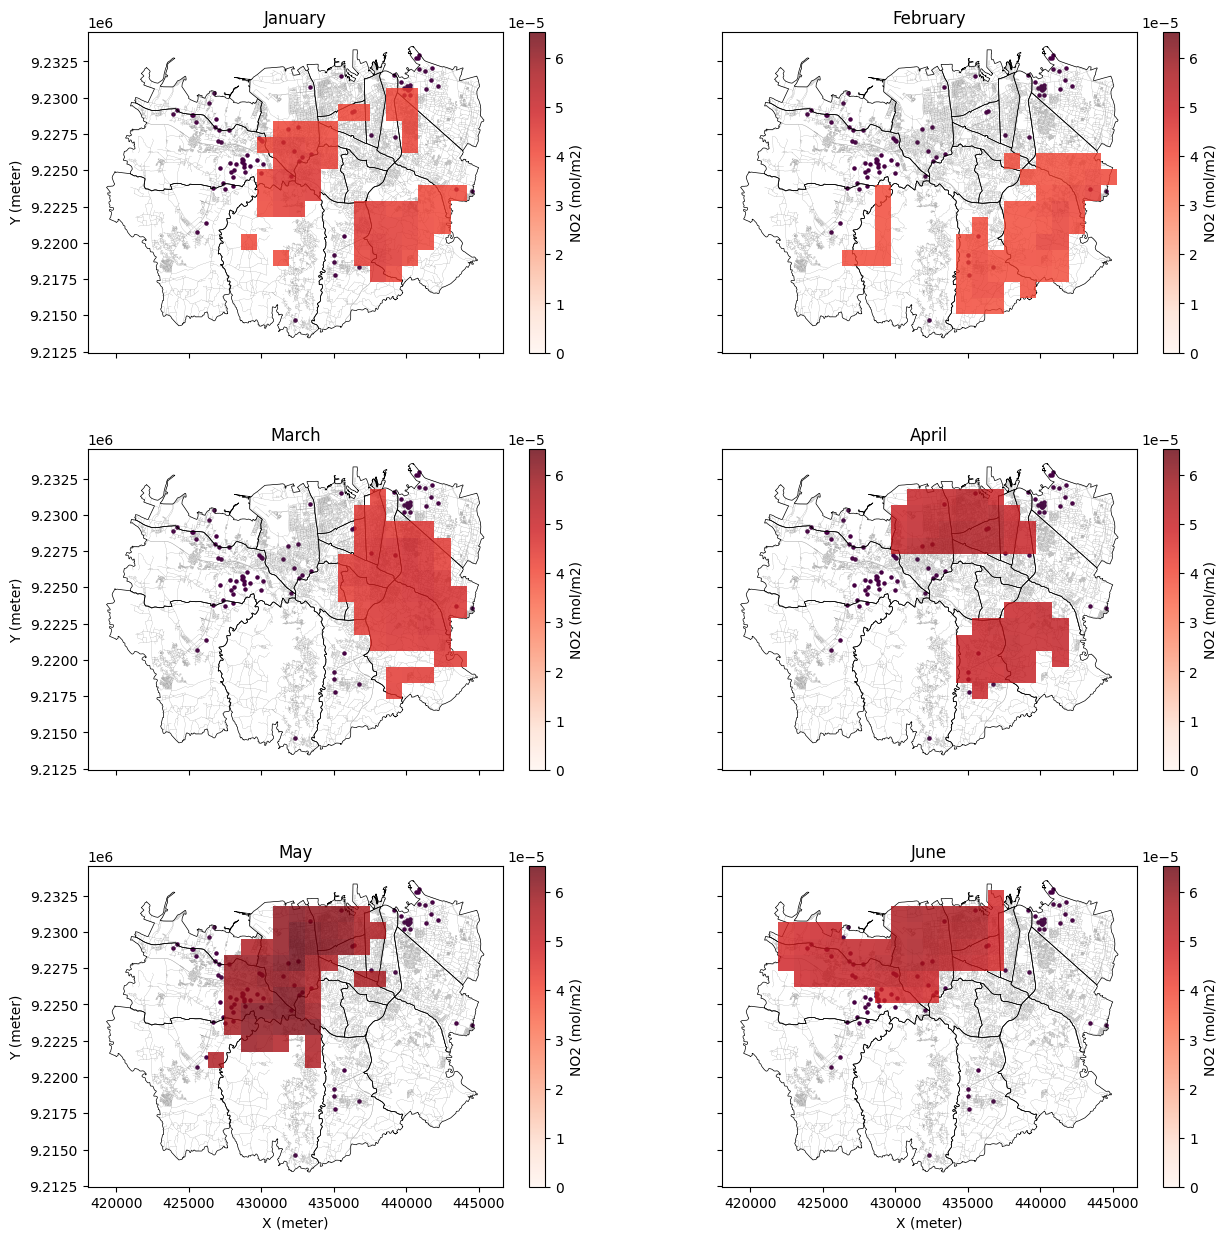

In [7]:
# Import Shapefile Batas Administrasi Semarang
shapefile_batas = r'C:\Users\zaviezra\Documents\UNDIP\TA\02skripsi\02processing\Data\DISTRICT'
shapefile_kec = gpd.read_file(os.path.join(shapefile_batas, 'district_semarang.shp'))

# Import Shapefile Jalan Semarang
shapefile_jalan = r'C:\Users\zaviezra\Documents\UNDIP\TA\02skripsi\02processing\Data\SHP'
shapefile_jln= gpd.read_file(os.path.join(shapefile_jalan, 'JLN_KotaSemarang.shp'))

shapefile_industri = r'C:\Users\zaviezra\Documents\UNDIP\TA\02skripsi\02processing\Data\SHP'
shapefile_ind = gpd.read_file(os.path.join(shapefile_industri, 'industry49s.shp'))
    
shapefile_kec = shapefile_kec.to_crs("EPSG:32749")
shapefile_jln = shapefile_jln.to_crs("EPSG:32749")
shapefile_ind = shapefile_ind.to_crs("EPSG:32749")

# Plotting
fig, axes = plt.subplots(3, 2, figsize=(15, 15), sharex=True, sharey=True)
month_name = ['January', 'February', 'March', 'April', 'May', 'June']
minx, miny, maxx, maxy = shapefile_kec.total_bounds
margin_x = (maxx - minx) * 0.05
margin_y = (maxy - miny) * 0.05 
for i, ax in enumerate(axes.flatten()):
    if i < len(month_name):
        month_i = monthly_mean.sel(month=i+1)
        month_i = month_i.rio.clip(shapefile_kec.geometry, shapefile_kec.crs, drop=True)

        # threshold P80
        data = month_i.values.flatten()
        data = data[~np.isnan(data)]
        p80 = np.percentile(data, 80)

        hotspot_i = month_i.where(month_i >= p80)

        hotspot_i.plot(
            ax=ax,
            cmap='Reds',
            vmin=0,
            vmax=np.nanmax(monthly_mean.values),
            alpha=0.8,
            zorder=4,
            cbar_kwargs={'label': 'NO2 (mol/m2)'}
        )

        shapefile_kec.boundary.plot(ax=ax, edgecolor='black', linewidth=0.5, zorder=3)
        shapefile_jln.plot(ax=ax, color="#505050", linewidth=0.1, zorder=2)
        shapefile_ind.plot(ax=ax, color="#460043", markersize=5, zorder=1)    
        ax.set_title(month_name[i])

        ax.set_xlabel("X (meter)")
        ax.set_ylabel("Y (meter)")
        ax.label_outer()
        ax.set_xlim(minx - margin_x, maxx + margin_x)
        ax.set_ylim(miny - margin_y, maxy + margin_y)
        ax.set_aspect('equal')
    else:
        ax.axis('on')

plt.subplots_adjust(wspace=0.2, hspace=0.3)
plt.show()

In [ ]:
from shapely.geometry import box
import warnings
warnings.filterwarnings('ignore')

MONTH_NAMES = ['January', 'February', 'March', 'April', 'May', 'June']
KOLOM_KECAMATAN = None  

OUTPUT_PATH = r'C:\Users\zaviezra\Documents\UNDIP\TA\02skripsi\02processing\Data\XSL_CSV'
OUTPUT_FILENAME = 'hotspot_luas_kecamatan.xlsx'


if KOLOM_KECAMATAN is None:
    kandidat = [c for c in shapefile_kec.columns
                if any(k in c.upper() for k in ['KEC', 'DISTRIC', 'NAMA', 'NAME', 'WILAYAH'])]
    if kandidat:
        KOLOM_KECAMATAN = kandidat[0]
        print(f"[INFO] Kolom kecamatan terdeteksi: '{KOLOM_KECAMATAN}'")
    else:
        print("[WARNING] Kolom kecamatan tidak terdeteksi otomatis.")
        print("Kolom yang tersedia:", list(shapefile_kec.columns))
        print("Set KOLOM_KECAMATAN secara manual di bagian KONFIGURASI.")
        raise ValueError("Kolom kecamatan tidak ditemukan.")


# ── 1. Resolusi piksel (meter²) ──────────────
res_x, res_y = monthly_mean.rio.resolution()
pixel_area_m2 = abs(res_x * res_y)
pixel_area_km2 = pixel_area_m2 / 1_000_000
print(f"[INFO] Resolusi piksel: {abs(res_x):.1f} x {abs(res_y):.1f} meter")
print(f"[INFO] Luas per piksel: {pixel_area_m2:,.0f} m² = {pixel_area_km2:.6f} km²\n")


# ── 2. Pastikan CRS sama ─────────────────────
kec_crs = shapefile_kec.crs
raster_crs = monthly_mean.rio.crs
if str(kec_crs) != str(raster_crs):
    shapefile_kec = shapefile_kec.to_crs(raster_crs)
    print(f"[INFO] Shapefile diproyeksikan ke: {raster_crs}")


# ── 3. Hitung luas hotspot per kecamatan ─────
results = []

for i, bulan in enumerate(MONTH_NAMES):
    m = i + 1
    print(f"Memproses: {bulan} (bulan ke-{m}) ...", end=' ')

    # Ambil data bulan + clip ke batas kota
    month_i = monthly_mean.sel(month=m)
    month_clipped = month_i.rio.clip(
        shapefile_kec.geometry,
        shapefile_kec.crs,
        drop=True,
        all_touched=False
    )

    # Threshold P80
    data_flat = month_clipped.values.flatten()
    data_valid = data_flat[~np.isnan(data_flat)]
    p80 = np.percentile(data_valid, 80)

    # Buat mask hotspot (True = hotspot)
    hotspot_mask = month_clipped >= p80

    # Dapatkan koordinat piksel hotspot
    lons = month_clipped.x.values
    lats = month_clipped.y.values
    mask_vals = hotspot_mask.values   # shape: (n_lat, n_lon)

    # Buat GeoDataFrame dari piksel hotspot
    half_x = abs(res_x) / 2
    half_y = abs(res_y) / 2

    pixel_geoms = []
    for row_idx in range(mask_vals.shape[0]):
        for col_idx in range(mask_vals.shape[1]):
            if mask_vals[row_idx, col_idx]:
                cx = lons[col_idx]
                cy = lats[row_idx]
                geom = box(cx - half_x, cy - half_y,
                           cx + half_x, cy + half_y)
                pixel_geoms.append(geom)

    if len(pixel_geoms) == 0:
        print(f"0 piksel hotspot — skip")
        for _, row in shapefile_kec.iterrows():
            results.append({
                'Kecamatan': row[KOLOM_KECAMATAN],
                'Bulan': bulan,
                'Luas_Hotspot_km2': 0.0,
                'Threshold_P80': p80
            })
        continue

    gdf_hotspot = gpd.GeoDataFrame(
        geometry=pixel_geoms,
        crs=raster_crs
    )

    # Intersect hotspot dengan setiap kecamatan
    for _, kec_row in shapefile_kec.iterrows():
        kec_name = kec_row[KOLOM_KECAMATAN]
        kec_geom = kec_row.geometry

        # Hitung piksel yang masuk ke kecamatan ini
        in_kec = gdf_hotspot[gdf_hotspot.geometry.intersects(kec_geom)]

        if len(in_kec) == 0:
            luas_km2 = 0.0
        else:
            # Hitung luas irisan agar piksel di batas tidak double-counted
            intersect_area = in_kec.geometry.intersection(kec_geom).area.sum()
            luas_km2 = intersect_area / 1_000_000

        results.append({
            'Kecamatan': kec_name,
            'Bulan': bulan,
            'Luas_Hotspot_km2': round(luas_km2, 4),
            'Threshold_P80': round(p80, 6)
        })

    print(f"{len(pixel_geoms):,} piksel hotspot ✓")


# 4. Buat DataFrame
df_long = pd.DataFrame(results)

# Pivot: baris = kecamatan, kolom = bulan
df_pivot = df_long.pivot_table(
    index='Kecamatan',
    columns='Bulan',
    values='Luas_Hotspot_km2',
    aggfunc='sum'
)[MONTH_NAMES].reset_index()

# Tambah kolom total
df_pivot['Total (km²)'] = df_pivot[MONTH_NAMES].sum(axis=1)

# Tambah baris total
total_row = pd.Series(
    [' TOTAL'] + df_pivot[MONTH_NAMES + ['Total (km²)']].sum().tolist(),
    index=df_pivot.columns
)
df_pivot = pd.concat([df_pivot, total_row.to_frame().T], ignore_index=True)

# Tabel threshold P80 per bulan
df_threshold = df_long.drop_duplicates('Bulan')[['Bulan', 'Threshold_P80']].set_index('Bulan').T
df_threshold.index = ['Threshold P80 (mol/m²)']


# ── 5. Print preview ──────────────────────────
print("\n" + "="*70)
print("LUAS HOTSPOT NO2 PER KECAMATAN PER BULAN (km²)")
print("="*70)
print(df_pivot.to_string(index=False))
print("\nThreshold P80:")
print(df_threshold.to_string())


# ── 6. Export ke Excel ────────────────────────
import os
from openpyxl import load_workbook
from openpyxl.styles import (Font, PatternFill, Alignment,
                              Border, Side, numbers)
from openpyxl.utils import get_column_letter

output_file = os.path.join(OUTPUT_PATH, OUTPUT_FILENAME)
os.makedirs(OUTPUT_PATH, exist_ok=True)

# --- Sheet 1: Tabel Pivot ---
with pd.ExcelWriter(output_file, engine='openpyxl') as writer:
    df_pivot.to_excel(writer, sheet_name='Luas per Kecamatan', index=False)
    df_long.to_excel(writer, sheet_name='Data Detail', index=False)

# --- Format Sheet 1 ---
wb = load_workbook(output_file)
ws = wb['Luas per Kecamatan']

COLOR_HEADER = 'C0392B'   # merah tua
COLOR_TOTAL  = 'F5B7B1'   # merah muda
COLOR_ALT    = 'FADBD8'   # merah sangat muda
WHITE        = 'FFFFFF'
GREY         = 'F2F2F2'

thin = Side(style='thin', color='AAAAAA')
border = Border(left=thin, right=thin, top=thin, bottom=thin)

header_font  = Font(name='Arial', bold=True, color=WHITE, size=11)
header_fill  = PatternFill('solid', start_color=COLOR_HEADER)
header_align = Alignment(horizontal='center', vertical='center', wrap_text=True)

total_font   = Font(name='Arial', bold=True, size=10)
total_fill   = PatternFill('solid', start_color=COLOR_TOTAL)

data_font    = Font(name='Arial', size=10)

n_rows = ws.max_row
n_cols = ws.max_column

for row in ws.iter_rows():
    for cell in row:
        cell.border = border
        if cell.row == 1:
            cell.font    = header_font
            cell.fill    = header_fill
            cell.alignment = header_align
        elif cell.row == n_rows:          # baris TOTAL
            cell.font = total_font
            cell.fill = total_fill
            cell.alignment = Alignment(horizontal='center')
        else:
            cell.font = data_font
            # warna selang-seling
            fill_color = GREY if cell.row % 2 == 0 else WHITE
            if cell.column == 1:
                cell.alignment = Alignment(horizontal='left')
            else:
                cell.alignment = Alignment(horizontal='center')
                cell.fill = PatternFill('solid', start_color=fill_color)
                # format angka desimal
                if isinstance(cell.value, (int, float)):
                    cell.number_format = '0.0000'

# Tambah baris threshold P80
ws.append([])
ws.append(['Threshold P80 (mol/m²)'] + [
    df_long[df_long.Bulan == b]['Threshold_P80'].iloc[0]
    for b in MONTH_NAMES
] + [''])

for cell in ws[ws.max_row]:
    cell.font = Font(name='Arial', italic=True, size=9, color='555555')
    if isinstance(cell.value, float):
        cell.number_format = '0.000000'

# Lebar kolom
ws.column_dimensions['A'].width = 28
for col in range(2, n_cols + 1):
    ws.column_dimensions[get_column_letter(col)].width = 14

ws.row_dimensions[1].height = 30

# Freeze header
ws.freeze_panes = 'B2'

wb.save(output_file)
print(f"\n[✓] File disimpan ke:\n    {output_file}")

[INFO] Kolom kecamatan terdeteksi: 'district'
[INFO] Resolusi piksel: 1113.2 x 1113.2 meter
[INFO] Luas per piksel: 1,239,214 m² = 1.239214 km²

Memproses: January (bulan ke-1) ... 60 piksel hotspot ✓
Memproses: February (bulan ke-2) ... 60 piksel hotspot ✓
Memproses: March (bulan ke-3) ... 60 piksel hotspot ✓
Memproses: April (bulan ke-4) ... 60 piksel hotspot ✓
Memproses: May (bulan ke-5) ... 60 piksel hotspot ✓
Memproses: June (bulan ke-6) ... 60 piksel hotspot ✓

LUAS HOTSPOT NO2 PER KECAMATAN PER BULAN (km²)
       Kecamatan  January February    March    April      May     June Total (km²)
      Banyumanik   6.5497  20.5624   1.3877  14.1114   0.0632      0.0     42.6744
       Candisari   0.0649   0.0576   5.9735   0.2476      0.0      0.0      6.3436
    Gajahmungkur    5.581      0.0   1.1087   0.0441    3.809   0.2794     10.8222
       Gayamsari   1.5136   0.0357   4.8797   2.3728   0.6691      0.0      9.4709
           Genuk   1.3485      0.0   2.1276      0.0      0.0     

In [12]:
from shapely.geometry import box
from shapely.ops import unary_union
import os
import warnings
warnings.filterwarnings('ignore')

# ─────────────────────────────────────────────
# KONFIGURASI
# ─────────────────────────────────────────────
MONTH_NAMES = ['Januari', 'Februari', 'Maret', 'April', 'Mei', 'Juni']

OUTPUT_PATH = r'C:\Users\zaviezra\Documents\UNDIP\TA\02skripsi\02processing\Data\XSL_CSV'
OUTPUT_FILENAME = 'hotspot_jalan_industri.xlsx'
# ─────────────────────────────────────────────


# ── 0. Pastikan CRS seragam (EPSG:32749) ─────
TARGET_CRS = "EPSG:32749"
raster_crs  = monthly_mean.rio.crs

def reproject_if_needed(gdf, crs):
    return gdf if str(gdf.crs) == str(crs) else gdf.to_crs(crs)

shapefile_kec = reproject_if_needed(shapefile_kec, TARGET_CRS)
shapefile_jln = reproject_if_needed(shapefile_jln, TARGET_CRS)
shapefile_ind = reproject_if_needed(shapefile_ind, TARGET_CRS)

# ── 1. Area kota keseluruhan (union semua kecamatan) ──
kota_polygon   = unary_union(shapefile_kec.geometry)
kota_area_km2  = kota_polygon.area / 1_000_000

total_industri = len(shapefile_ind)
print(f"[INFO] Total titik industri : {total_industri}")
print(f"[INFO] Luas kota (union kec): {kota_area_km2:.2f} km²\n")

# ── 2. Panjang jalan total dalam kota (meter) ──
# Clip jalan ke batas kota dulu agar tidak ada jalan luar wilayah
jln_clip = gpd.clip(shapefile_jln, kota_polygon)
total_jalan_km = jln_clip.geometry.length.sum() / 1000
print(f"[INFO] Total panjang jalan dalam kota: {total_jalan_km:.2f} km\n")

# ── 3. Helper: konversi raster hotspot → poligon ──
def buat_hotspot_polygon(month_xr, shapefile_kec):
    """
    Clip → P80 → union piksel hotspot → kembalikan (hotspot_poly, non_hotspot_poly)
    """
    res_x, res_y = month_xr.rio.resolution()
    half_x, half_y = abs(res_x) / 2, abs(res_y) / 2

    # Clip ke batas kota
    m_clip = month_xr.rio.clip(
        shapefile_kec.geometry, shapefile_kec.crs,
        drop=True, all_touched=False
    )

    # Threshold P80
    flat = m_clip.values.flatten()
    valid = flat[~np.isnan(flat)]
    p80   = np.percentile(valid, 80)

    # Piksel hotspot → list box geometri
    lons      = m_clip.x.values
    lats      = m_clip.y.values
    mask_vals = (m_clip >= p80).values

    geoms = [
        box(lons[c] - half_x, lats[r] - half_y,
            lons[c] + half_x, lats[r] + half_y)
        for r in range(mask_vals.shape[0])
        for c in range(mask_vals.shape[1])
        if mask_vals[r, c]
    ]

    if not geoms:
        return None, kota_polygon, p80

    hotspot_poly     = unary_union(geoms).intersection(kota_polygon)
    non_hotspot_poly = kota_polygon.difference(hotspot_poly)

    return hotspot_poly, non_hotspot_poly, p80


# ── 4. Hitung metrik per bulan ────────────────
results = []

for i, bulan in enumerate(MONTH_NAMES):
    m = i + 1
    print(f"Memproses {bulan} ...", end=' ')

    month_i = monthly_mean.sel(month=m)
    hotspot_poly, non_hotspot_poly, p80 = buat_hotspot_polygon(month_i, shapefile_kec)

    if hotspot_poly is None or hotspot_poly.is_empty:
        print("hotspot kosong — skip")
        results.append({
            'Bulan': bulan,
            'Kepadatan Jalan Hotspot (km/km²)': np.nan,
            'Kepadatan Jalan Non-Hotspot (km/km²)': np.nan,
            'Industri pada Hotspot': 0,
            'Persentase (%)': 0.0,
            'Threshold P80': p80,
            'Luas Hotspot (km²)': 0.0,
            'Luas Non-Hotspot (km²)': non_hotspot_poly.area / 1_000_000,
        })
        continue

    # ── Luas area (km²)
    luas_hotspot_km2     = hotspot_poly.area     / 1_000_000
    luas_non_hotspot_km2 = non_hotspot_poly.area / 1_000_000

    # ── Kepadatan jalan ──────────────────────────────────
    # Clip jalan ke hotspot
    jln_hs = gpd.clip(jln_clip, hotspot_poly)
    pjg_jln_hs_km = jln_hs.geometry.length.sum() / 1000 if len(jln_hs) > 0 else 0.0

    # Clip jalan ke non-hotspot
    jln_nhs = gpd.clip(jln_clip, non_hotspot_poly)
    pjg_jln_nhs_km = jln_nhs.geometry.length.sum() / 1000 if len(jln_nhs) > 0 else 0.0

    kp_hs  = pjg_jln_hs_km  / luas_hotspot_km2     if luas_hotspot_km2     > 0 else 0.0
    kp_nhs = pjg_jln_nhs_km / luas_non_hotspot_km2 if luas_non_hotspot_km2 > 0 else 0.0

    # ── Industri dalam hotspot ───────────────────────────
    ind_in_hs   = shapefile_ind[shapefile_ind.geometry.within(hotspot_poly)]
    n_ind_hs    = len(ind_in_hs)
    pct_ind     = (n_ind_hs / total_industri * 100) if total_industri > 0 else 0.0

    results.append({
        'Bulan'                              : bulan,
        'Kepadatan Jalan Hotspot (km/km²)'  : round(kp_hs,  2),
        'Kepadatan Jalan Non-Hotspot (km/km²)': round(kp_nhs, 2),
        'Industri pada Hotspot'             : n_ind_hs,
        'Persentase (%)'                    : round(pct_ind, 2),
        'Threshold P80'                     : round(p80, 6),
        'Luas Hotspot (km²)'                : round(luas_hotspot_km2, 4),
        'Luas Non-Hotspot (km²)'            : round(luas_non_hotspot_km2, 4),
    })

    print(f"Hotspot={luas_hotspot_km2:.2f} km²  |  "
          f"Jln HS={kp_hs:.2f}  NHS={kp_nhs:.2f} km/km²  |  "
          f"Industri={n_ind_hs} ({pct_ind:.2f}%) ✓")


# ── 5. DataFrame & print ──────────────────────
df = pd.DataFrame(results)

TAMPIL_COLS = [
    'Bulan',
    'Kepadatan Jalan Hotspot (km/km²)',
    'Kepadatan Jalan Non-Hotspot (km/km²)',
    'Industri pada Hotspot',
    'Persentase (%)',
]

print("\n" + "="*75)
print("KEPADATAN JALAN & PERSEBARAN INDUSTRI PADA HOTSPOT NO2 VCD")
print(f"(Total industri dalam kota: {total_industri} titik)")
print("="*75)
print(df[TAMPIL_COLS].to_string(index=False))


# ── 6. Export Excel ───────────────────────────
from openpyxl import load_workbook
from openpyxl.styles import Font, PatternFill, Alignment, Border, Side
from openpyxl.utils import get_column_letter

os.makedirs(OUTPUT_PATH, exist_ok=True)
output_file = os.path.join(OUTPUT_PATH, OUTPUT_FILENAME)

# Sheet 1: tabel ringkasan (sesuai tabel di laporan)
df_ringkasan = df[TAMPIL_COLS].copy()

# Sheet 2: data lengkap
df_lengkap = df.copy()

with pd.ExcelWriter(output_file, engine='openpyxl') as writer:
    df_ringkasan.to_excel(writer, sheet_name='Ringkasan', index=False)
    df_lengkap.to_excel(writer, sheet_name='Data Lengkap', index=False)

# ── Format Sheet Ringkasan ────────────────────
wb = load_workbook(output_file)
ws = wb['Ringkasan']

# Warna
C_HEADER   = 'C0392B'   # merah tua
C_HS_COL   = 'FADBD8'   # merah muda  (kolom hotspot)
C_NHS_COL  = 'D5E8D4'   # hijau muda  (kolom non-hotspot)
C_IND_COL  = 'FFF3CD'   # kuning muda (industri)
C_ALT      = 'F9F9F9'
WHITE      = 'FFFFFF'

thin   = Side(style='thin', color='BBBBBB')
border = Border(left=thin, right=thin, top=thin, bottom=thin)

# Header
for cell in ws[1]:
    cell.font      = Font(name='Arial', bold=True, color=WHITE, size=10)
    cell.fill      = PatternFill('solid', start_color=C_HEADER)
    cell.alignment = Alignment(horizontal='center', vertical='center', wrap_text=True)
    cell.border    = border

ws.row_dimensions[1].height = 36

# Data rows
col_colors = {
    1: WHITE,       # Bulan
    2: C_HS_COL,    # Kepadatan Jalan Hotspot
    3: C_NHS_COL,   # Kepadatan Jalan Non-Hotspot
    4: C_IND_COL,   # Industri pada Hotspot
    5: C_IND_COL,   # Persentase
}

for row in ws.iter_rows(min_row=2, max_row=ws.max_row):
    for cell in row:
        cell.border = border
        cell.font   = Font(name='Arial', size=10)
        bg = col_colors.get(cell.column, WHITE)
        # selang-seling lebih terang di baris genap
        if cell.row % 2 == 0 and bg == WHITE:
            bg = C_ALT
        cell.fill = PatternFill('solid', start_color=bg)
        if cell.column == 1:
            cell.alignment = Alignment(horizontal='left', vertical='center')
        else:
            cell.alignment = Alignment(horizontal='center', vertical='center')
        if isinstance(cell.value, float):
            cell.number_format = '0.00'

# Tambah baris total industri sebagai catatan
ws.append([])
note_row = ws.max_row + 1
ws.cell(note_row, 1, f'*Total industri di dalam wilayah kota: {total_industri} titik')
ws.cell(note_row, 1).font = Font(name='Arial', italic=True, size=9, color='666666')

# Lebar kolom
widths = [14, 26, 30, 24, 16]
for col_idx, w in enumerate(widths, start=1):
    ws.column_dimensions[get_column_letter(col_idx)].width = w

# Freeze
ws.freeze_panes = 'B2'

# ── Format Sheet Data Lengkap ─────────────────
ws2 = wb['Data Lengkap']
for cell in ws2[1]:
    cell.font      = Font(name='Arial', bold=True, color=WHITE, size=10)
    cell.fill      = PatternFill('solid', start_color='2C3E50')
    cell.alignment = Alignment(horizontal='center', wrap_text=True)
    cell.border    = border
ws2.row_dimensions[1].height = 30
for col in ws2.columns:
    ws2.column_dimensions[get_column_letter(col[0].column)].width = 22
ws2.freeze_panes = 'B2'

wb.save(output_file)
print(f"\n[✓] File disimpan ke:\n    {output_file}")

[INFO] Total titik industri : 82
[INFO] Luas kota (union kec): 369.75 km²

[INFO] Total panjang jalan dalam kota: 3071.99 km

Memproses Januari ... Hotspot=74.14 km²  |  Jln HS=10.54  NHS=7.75 km/km²  |  Industri=21 (25.61%) ✓
Memproses Februari ... Hotspot=72.68 km²  |  Jln HS=7.26  NHS=8.57 km/km²  |  Industri=6 (7.32%) ✓
Memproses Maret ... Hotspot=73.33 km²  |  Jln HS=11.95  NHS=7.41 km/km²  |  Industri=3 (3.66%) ✓
Memproses April ... Hotspot=74.01 km²  |  Jln HS=11.76  NHS=7.44 km/km²  |  Industri=10 (12.20%) ✓
Memproses Mei ... Hotspot=74.01 km²  |  Jln HS=11.80  NHS=7.44 km/km²  |  Industri=34 (41.46%) ✓
Memproses Juni ... Hotspot=71.92 km²  |  Jln HS=12.39  NHS=7.32 km/km²  |  Industri=33 (40.24%) ✓

KEPADATAN JALAN & PERSEBARAN INDUSTRI PADA HOTSPOT NO2 VCD
(Total industri dalam kota: 82 titik)
   Bulan  Kepadatan Jalan Hotspot (km/km²)  Kepadatan Jalan Non-Hotspot (km/km²)  Industri pada Hotspot  Persentase (%)
 Januari                             10.54                       